## Assignment 1: Artificial Neural Networks
### Author : Songyu Qi 
### ZID: z5536858

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

data_filepath = 'Dataset/Nino3.4_data.csv'
test_years_filepath = 'Dataset/test_years.csv'

try:
    df = pd.read_csv(data_filepath)
    test_years_df = pd.read_csv(test_years_filepath)
    print(f"Data rows: {len(df)}")
    print(f"Test years rows: {len(test_years_df)}")
except FileNotFoundError:
    print(f"Input Error")

#Split Dataset as per instructions
test_years = test_years_df['year'].tolist()
test_set = df[df['year'].isin(test_years)]
train_val_set = df[~df['year'].isin(test_years)]

#Split train and validation set
train_set, val_set = train_test_split(train_val_set, test_size=0.2, random_state=42) 

print(f"Train set size: {train_set.shape}")
print(f"Validation set size: {val_set.shape}")
print(f"Test set size: {test_set.shape}")


#Define Features and Target
input_features = ['nino_tminus2', 'nino_tminus1', 'nino_t'] #time sequences
target_variable = 'nino_tplus1' 

X_train, y_train = train_set[input_features], train_set[target_variable]
X_val, y_val = val_set[input_features], val_set[target_variable]  
X_test, y_test = test_set[input_features], test_set[target_variable]


#Standardize Data
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

print(f"Original training data mean: {np.mean(X_train.values, axis=0)}")
print(f"Standardized training data mean: {np.mean(X_train_scaled, axis=0)}")
print(f"Standardized training data std: {np.std(X_train_scaled, axis=0)}")

#Save the Scaler
scaler_filename = 'feature_scaler.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(feature_scaler, f)

Data rows: 802
Test years rows: 6
Train set size: (584, 11)
Validation set size: (146, 11)
Test set size: (72, 11)
Original training data mean: [-0.18472603 -0.1864726  -0.19183219]
Standardized training data mean: [-9.12512075e-18  3.80213365e-17 -3.04170692e-18]
Standardized training data std: [1. 1. 1.]



nino_tplus1:
train loss: 0.0546, val loss: 0.0671

nino_tplus2:
train loss: 0.1553, val loss: 0.1785

nino_tplus3:
train loss: 0.2490, val loss: 0.2525

nino_tplus4:
train loss: 0.3300, val loss: 0.3429

nino_tplus5:
train loss: 0.4037, val loss: 0.4171

nino_tplus6:
train loss: 0.4748, val loss: 0.4665

nino_tplus6_transferlearning:
train loss: 0.4772, val loss: 0.4670


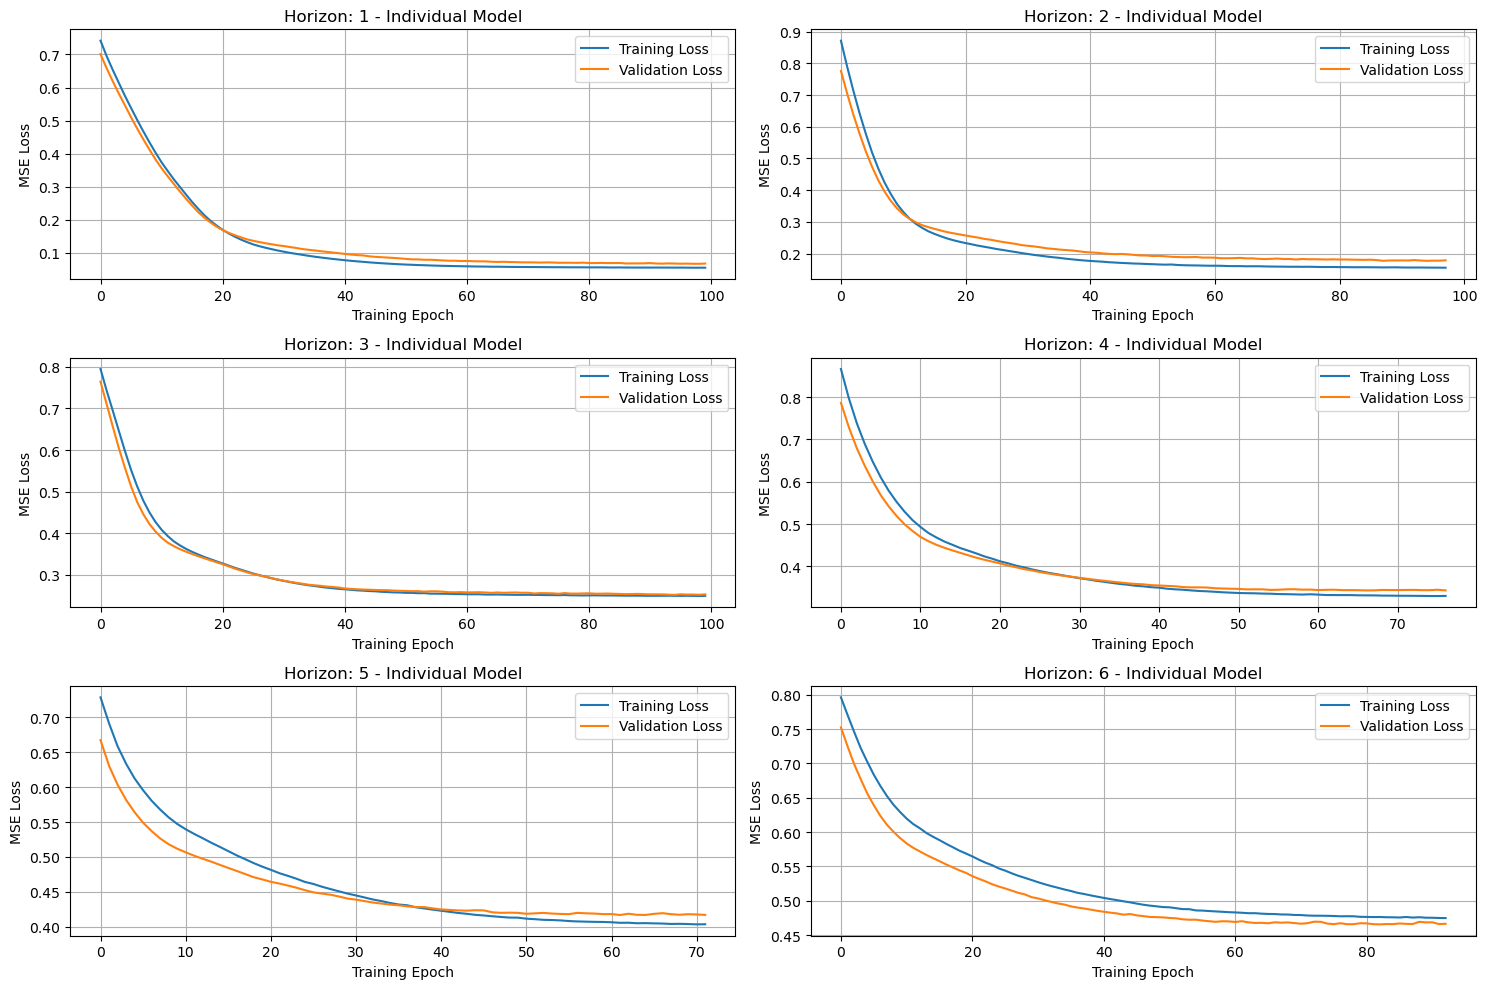

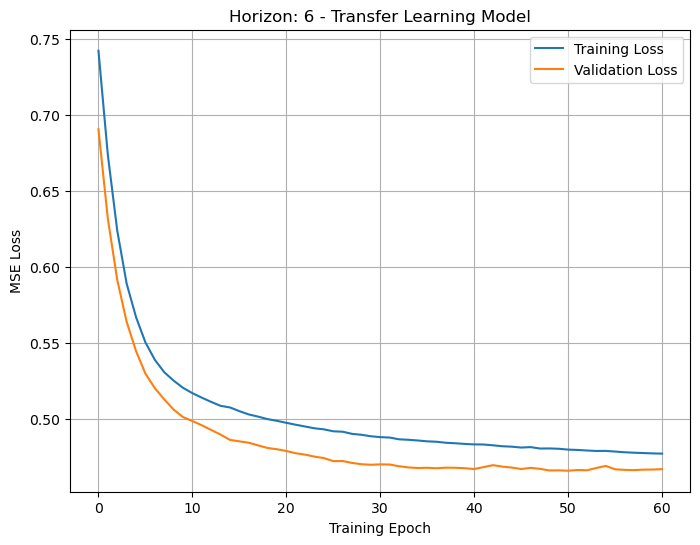

In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

class RegressionNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(RegressionNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), 
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )
    def forward(self, x):
        return self.network(x)

def train_model(target_variable_name, input_dim, output_dim, train_loader, val_loader, base_model_path=None):
    print(f"\n{target_variable_name}:")
    model = RegressionNN(input_dim, output_dim)
    
    if base_model_path:
        model.load_state_dict(torch.load(base_model_path))
        
    learning_rate = 0.0001
    num_epochs = 100 
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    #weight_decay is used to prevent overfitting
    
    patience = 10
    best_val_loss = float('inf')
    patience_counter = 0
    min_delta = 1e-4
    model_filename = f'model_{target_variable_name}.pth'

    train_losses, val_losses = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_filename)
        else:
            patience_counter += 1
        
        if patience_counter == patience:
            break
            
    print(f"train loss: {train_losses[-1]:.4f}, val loss: {val_losses[-1]:.4f}")
    return train_losses, val_losses, model_filename

input_dim = X_train_scaled.shape[1]
output_dim = 1 
targets_to_train = [f'nino_tplus{i}' for i in range(1, 7)]
individual_histories = {}
base_model_for_transfer = None

for i, target in enumerate(targets_to_train):
    y_train_tensor = torch.tensor(train_set[target].values, dtype=torch.float32).view(-1, 1)#reshape 1column
    y_val_tensor = torch.tensor(val_set[target].values, dtype=torch.float32).view(-1, 1)
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=32)
    
    train_hist, val_hist, saved_model_path = train_model(
        target_variable_name=target,
        input_dim=input_dim, output_dim=output_dim,
        train_loader=train_loader, val_loader=val_loader,
        base_model_path=None
    )
    
    individual_histories[target] = {'train': train_hist, 'val': val_hist}

    if i == 0:
        base_model_for_transfer = saved_model_path


transfer_target = 'nino_tplus6'
transfer_model_name = 'nino_tplus6_transferlearning' 
transfer_histories = {}
'''
y_train_tensor = torch.tensor(train_set[transfer_target].values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(val_set[transfer_target].values, dtype=torch.float32).view(-1, 1)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32)
'''
train_hist, val_hist, saved_model_path = train_model(
    target_variable_name=transfer_model_name,
    input_dim=input_dim, output_dim=output_dim,
    train_loader=train_loader, val_loader=val_loader,
    base_model_path=base_model_for_transfer
)
transfer_histories[transfer_model_name] = {'train': train_hist, 'val': val_hist}

plt.figure(figsize=(15, 10))
for idx, (target, history) in enumerate(individual_histories.items(), 1):
    plt.subplot(3, 2, idx)
    plt.plot(history['train'], label='Training Loss')
    plt.plot(history['val'], label='Validation Loss')
    horizon_month = target.replace('nino_tplus', '')
    plt.title(f'Horizon: {horizon_month} - Individual Model')
    plt.xlabel('Training Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
history = transfer_histories[transfer_model_name]
plt.plot(history['train'], label='Training Loss')
plt.plot(history['val'], label='Validation Loss')
plt.title('Horizon: 6 - Transfer Learning Model')
plt.xlabel('Training Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# Model Evaluation
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pearson_correlation(y_true, y_pred):
    corr, _ = pearsonr(y_true, y_pred)
    return corr

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

evaluation_results = []
models_to_evaluate = targets_to_train + [transfer_model_name] #prepare models

for model_name in models_to_evaluate:
    model = RegressionNN(input_dim, output_dim)
    
    model_path = f'model_{model_name}.pth'
    model.load_state_dict(torch.load(model_path))
    model.eval() 
    
    with torch.no_grad():
        predictions_tensor = model(X_test_tensor)
    
    predictions = predictions_tensor.numpy().flatten()
    
    #judge if transfer learning model
    if 'transfer' in model_name:
        true_target_col = 'nino_tplus6'
    else:
        true_target_col = model_name
        
    true_values = test_set[true_target_col].values
    
    rmse_score = rmse(true_values, predictions)
    correlation_score = pearson_correlation(true_values, predictions)
    
    evaluation_results.append({
        'Model': model_name,
        'RMSE': rmse_score,
        'Correlation': correlation_score
    })

results_df = pd.DataFrame(evaluation_results)
results_df.set_index('Model', inplace=True)

print("\n--- Task A: Model Evaluation Results on Test Set ---")
print(results_df)


--- Task A: Model Evaluation Results on Test Set ---
                                  RMSE  Correlation
Model                                              
nino_tplus1                   0.190627     0.981154
nino_tplus2                   0.377525     0.926077
nino_tplus3                   0.523718     0.846638
nino_tplus4                   0.654005     0.753525
nino_tplus5                   0.747434     0.661343
nino_tplus6                   0.819519     0.568530
nino_tplus6_transferlearning  0.806913     0.579691


torch.Size([584, 6])
torch.Size([146, 6])
train loss: 0.2828, val loss: 0.2887


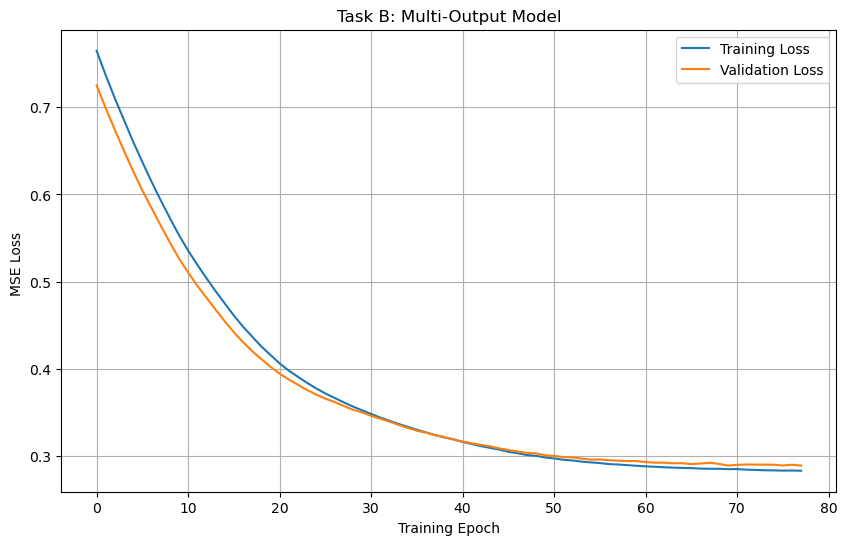

(72, 6)


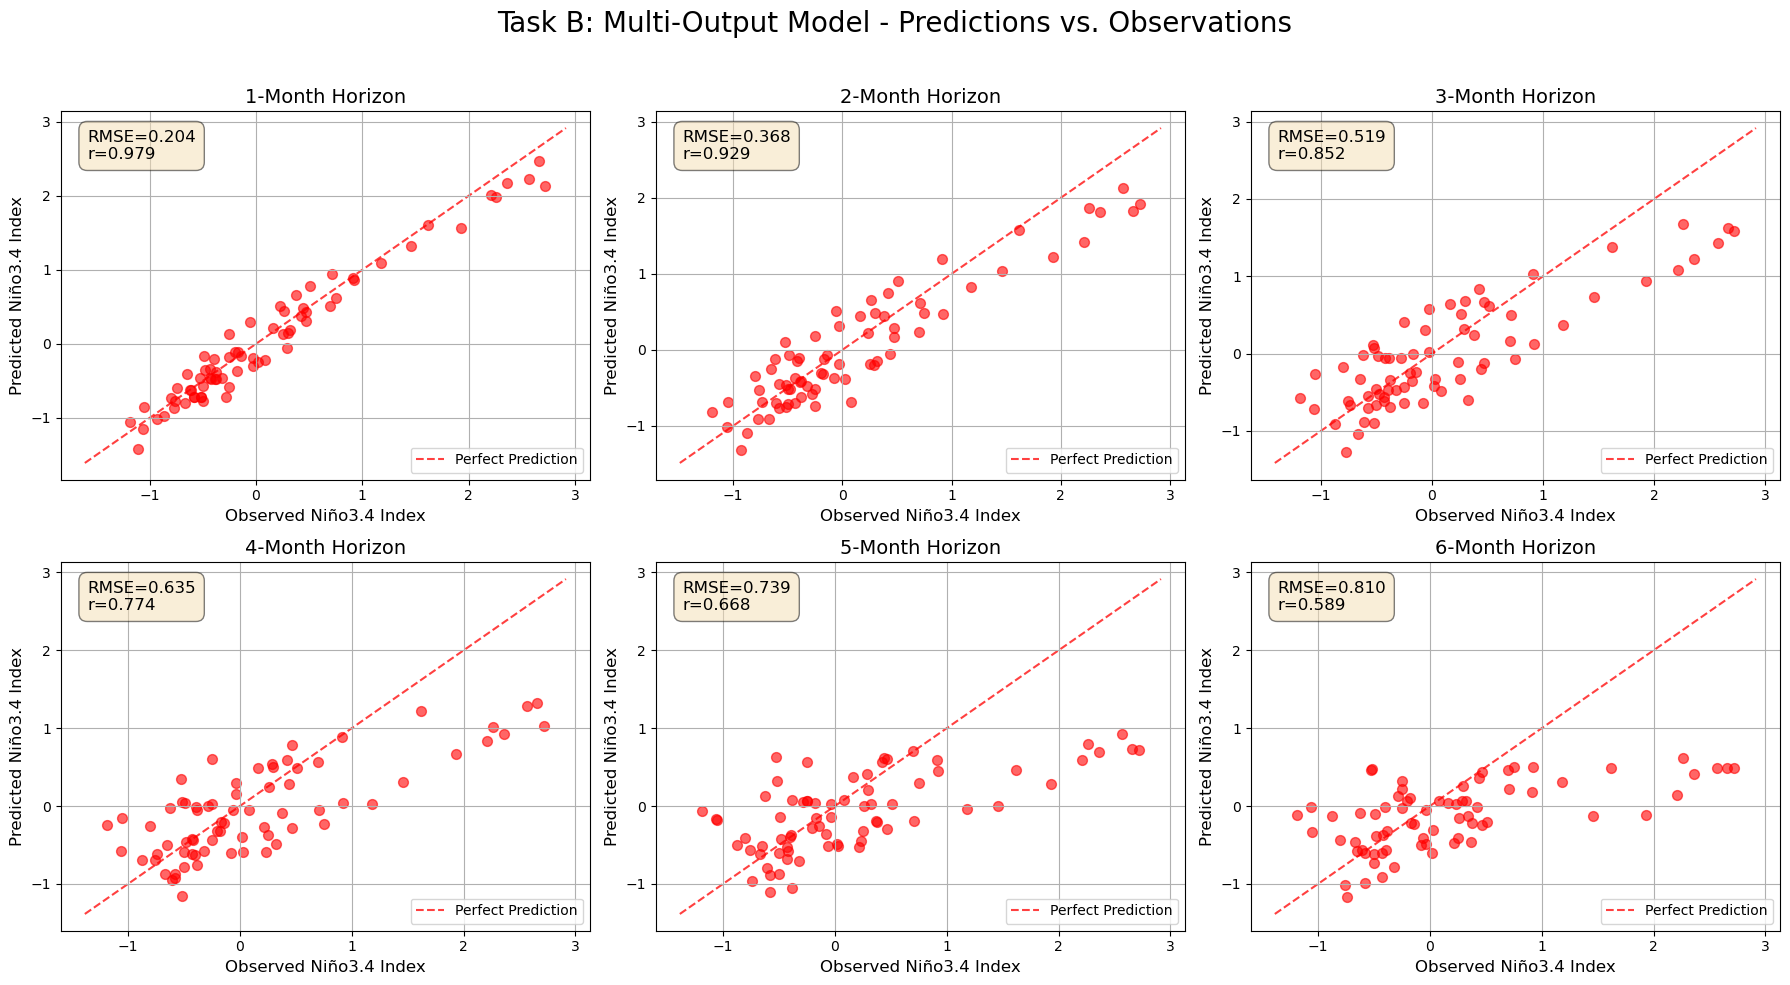

In [11]:
target_variables = [f'nino_tplus{i}' for i in range(1, 7)]
y_train = train_set[target_variables]
y_val = val_set[target_variables]

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)   
print(y_train_tensor.shape)
print(y_val_tensor.shape)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

class MultiOutputNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(MultiOutputNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_tensor.shape[1]
output_dim = y_train_tensor.shape[1] 
model_taskB = MultiOutputNN(input_dim, output_dim)


learning_rate = 0.0001
num_epochs = 100
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model_taskB.parameters(), lr=learning_rate, weight_decay=1e-5)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience = 8
patient_counter = 0
min_delta = 1e-4  
model_save_path = 'model_taskB.pth'

for epoch in range(num_epochs):
    model_taskB.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        outputs = model_taskB(inputs) 
        loss = criterion(outputs, labels) 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model_taskB.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model_taskB(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
    
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_taskB.state_dict(), model_save_path)
    else:
        patience_counter += 1
    
    if patience_counter == patience:
        break
print(f'train loss: {epoch_train_loss:.4f}, val loss: {epoch_val_loss:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Task B: Multi-Output Model')
plt.xlabel('Training Epoch')
plt.ylabel('MSE Loss ')
plt.legend()
plt.grid(True)
plt.show()

#model_taskB = MultiOutputNN(input_dim, output_dim)

#model_path = 'model_taskB.pth' 
#model_taskB.load_state_dict(torch.load(model_path))
model_taskB.eval() 

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
with torch.no_grad():
    predictions_tensor = model_taskB(X_test_tensor)

predictions_np = predictions_tensor.numpy()
print(predictions_np.shape)

target_variables = [f'nino_tplus{i}' for i in range(1, 7)]
subplot_titles = ['1-Month Horizon', '2-Month Horizon', '3-Month Horizon', 
                  '4-Month Horizon', '5-Month Horizon', '6-Month Horizon']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() 

for i, ax in enumerate(axes):
    y_true = test_set[target_variables[i]].values
    y_pred = predictions_np[:, i] 
    
    taskB_rmse_val = rmse(y_true, y_pred)
    taskB_corr_val = pearson_correlation(y_true, y_pred)

    ax.scatter(y_true, y_pred, c='r', alpha=0.6, s=50)
    
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction')
    
    ax.set_title(subplot_titles[i], fontsize=14)
    ax.set_xlabel('Observed Niño3.4 Index', fontsize=12)
    ax.set_ylabel('Predicted Niño3.4 Index', fontsize=12)
    
    annotation = f'RMSE={taskB_rmse_val:.3f}\nr={taskB_corr_val:.3f}'
    ax.text(0.05, 0.95, annotation, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
            
    ax.grid(True)
    ax.legend()

fig.suptitle('Task B: Multi-Output Model - Predictions vs. Observations', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

weights: [1.5957448  1.2765958  1.2287235  0.95744693 0.6702128  0.27127662]
train loss: 0.2217, val loss: 0.2336


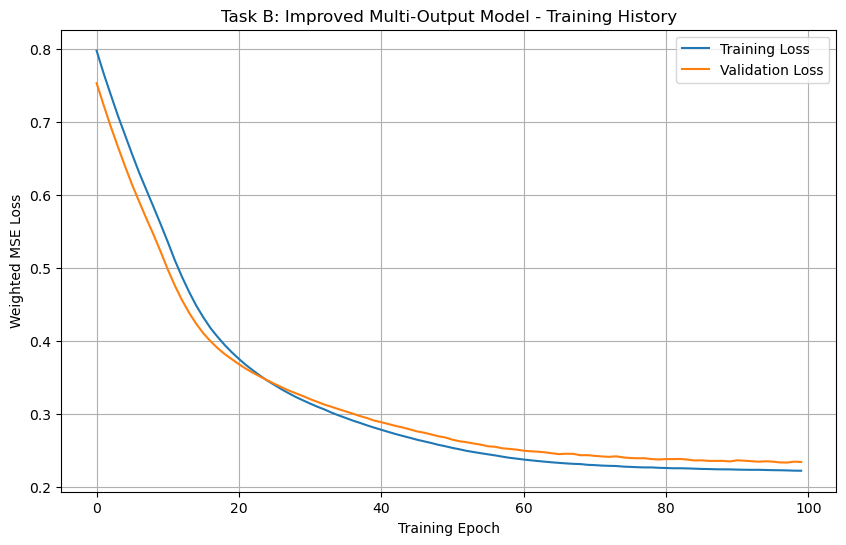

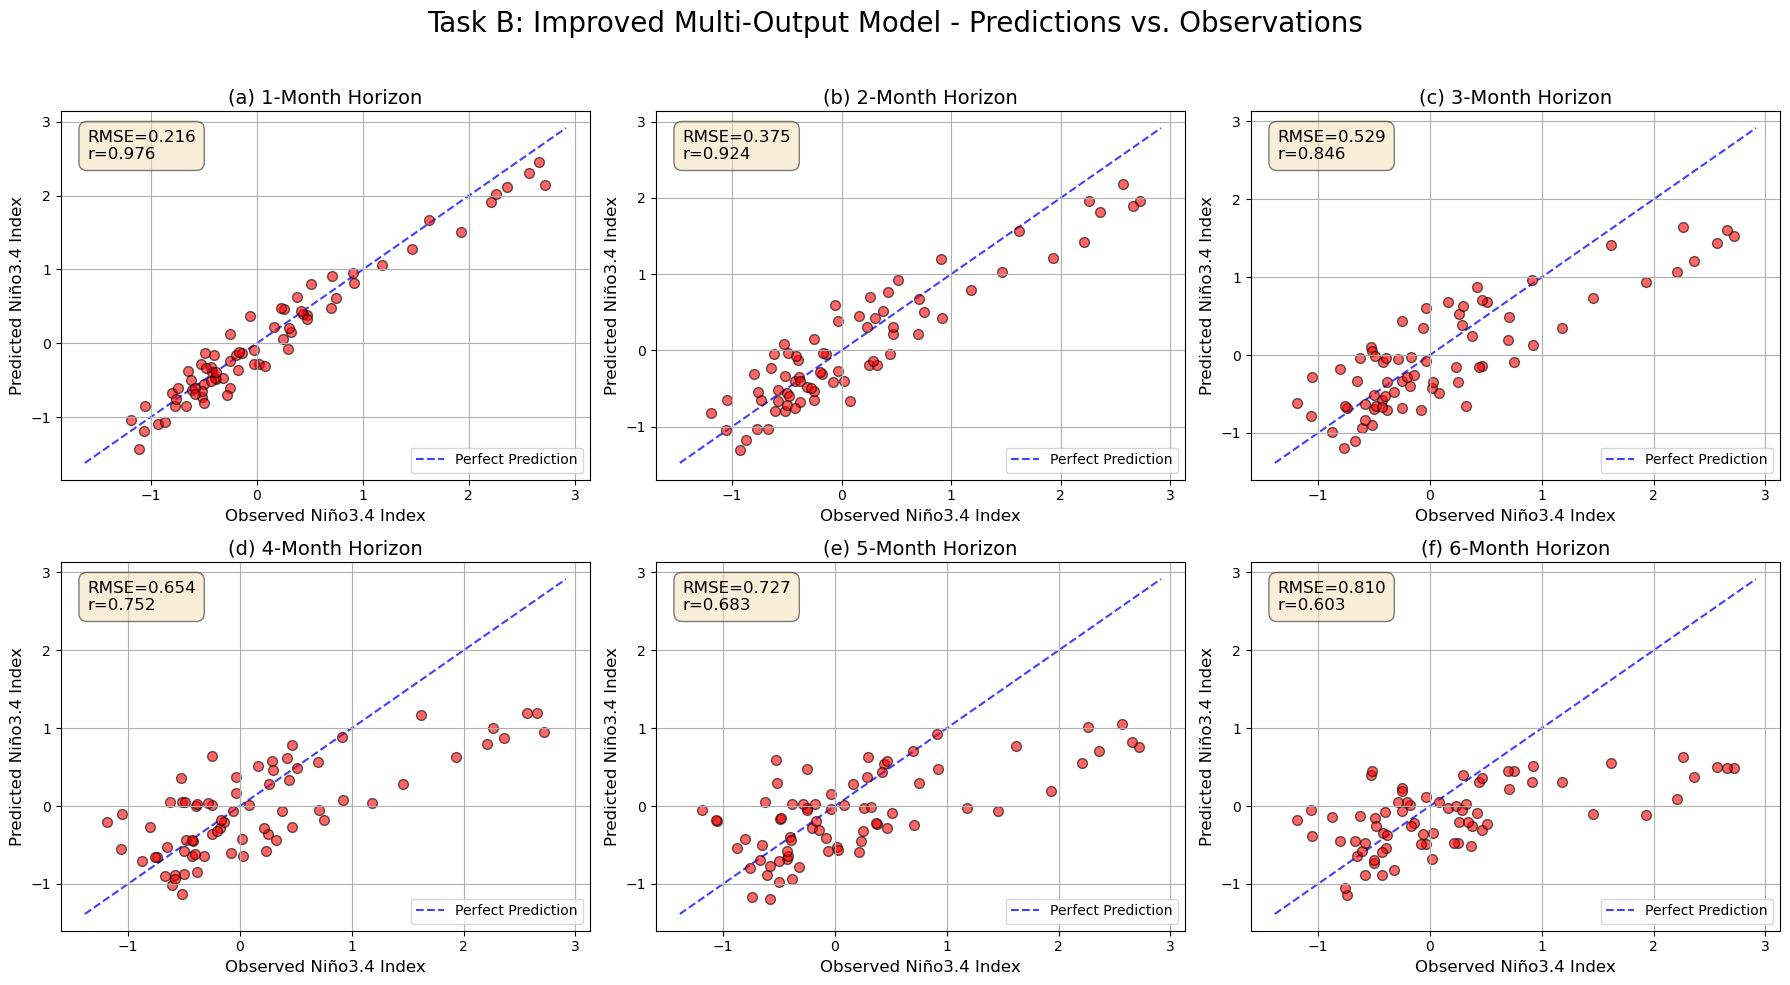

In [8]:
def weighted_mse_loss(outputs, labels, weights):
    squared_errors = (outputs - labels) ** 2
    weighted_squared_errors = squared_errors * weights

    return torch.mean(weighted_squared_errors)


weights = torch.tensor([1.0, 0.8, 0.77, 0.6, 0.42, 0.17], dtype=torch.float32)
weights = weights / torch.mean(weights) #standardize weights

input_dim = X_train_scaled.shape[1]
output_dim = 6
improved_model_taskB = MultiOutputNN(input_dim, output_dim) 
'''
target_variables = [f'nino_tplus{i}' for i in range(1, 7)]
y_train = train_set[target_variables]
y_val = val_set[target_variables]
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)
'''
learning_rate = 0.0001
num_epochs = 100
optimizer = torch.optim.Adam(improved_model_taskB.parameters(), lr=learning_rate, weight_decay=1e-5)
model_save_path = 'improved_model_taskB.pth'

train_losses, val_losses = [], []
print(f"weights: {weights.numpy()}")

for epoch in range(num_epochs):
    improved_model_taskB.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        outputs = improved_model_taskB(inputs)
        
        loss = weighted_mse_loss(outputs, labels, weights)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    improved_model_taskB.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = improved_model_taskB(inputs)

            loss = weighted_mse_loss(outputs, labels, weights)
            running_val_loss += loss.item() * inputs.size(0)
    
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

print(f'train loss: {train_losses[-1]:.4f}, val loss: {val_losses[-1]:.4f}')

torch.save(improved_model_taskB.state_dict(), model_save_path)

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Task B: Improved Multi-Output Model - Training History')
plt.xlabel('Training Epoch')
plt.ylabel('Weighted MSE Loss')
plt.legend()
plt.grid(True)
plt.show()
'''
input_dim = X_train_scaled.shape[1]
output_dim = 6
improved_model_taskB = MultiOutputNN(input_dim, output_dim)

model_path = 'improved_model_taskB.pth' 
improved_model_taskB.load_state_dict(torch.load(model_path))
'''
improved_model_taskB.eval() 
with torch.no_grad():
    predictions_tensor = improved_model_taskB(X_test_tensor)

predictions_np = predictions_tensor.numpy()

target_variables = [f'nino_tplus{i}' for i in range(1, 7)]
subplot_titles = ['(a) 1-Month Horizon', '(b) 2-Month Horizon', '(c) 3-Month Horizon', 
                  '(d) 4-Month Horizon', '(e) 5-Month Horizon', '(f) 6-Month Horizon']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() 

for i, ax in enumerate(axes):
    y_true = test_set[target_variables[i]].values
    y_pred = predictions_np[:, i]
    
    improved_model_taskB_rmse_val = rmse(y_true, y_pred)
    improved_model_taskB_corr_val = pearson_correlation(y_true, y_pred)
    
    ax.scatter(y_true, y_pred, c='r', alpha=0.6, edgecolors='k', s=50)
        
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'b--', alpha=0.75, zorder=0, label='Perfect Prediction')
    
    ax.set_title(subplot_titles[i], fontsize=14)
    ax.set_xlabel('Observed Niño3.4 Index', fontsize=12)
    ax.set_ylabel('Predicted Niño3.4 Index', fontsize=12)
    
    annotation = f'RMSE={improved_model_taskB_rmse_val:.3f}\nr={improved_model_taskB_corr_val:.3f}'
    ax.text(0.05, 0.95, annotation, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
            
    ax.grid(True)
    ax.legend()

fig.suptitle('Task B: Improved Multi-Output Model - Predictions vs. Observations', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

       Task A (Individual)             Task B (Standard)              \
                      RMSE Correlation              RMSE Correlation   
tplus1              0.1906      0.9812            0.2115      0.9785   
tplus2              0.3775      0.9261            0.3757      0.9283   
tplus3              0.5237      0.8466            0.5287      0.8506   
tplus4              0.6540      0.7535            0.6446      0.7737   
tplus5              0.7474      0.6613            0.7502      0.6639   
tplus6              0.8195      0.5685            0.8184      0.5889   

       Task B (Improved)              
                    RMSE Correlation  
tplus1            0.2162      0.9761  
tplus2            0.3747      0.9236  
tplus3            0.5286      0.8458  
tplus4            0.6541      0.7519  
tplus5            0.7272      0.6828  
tplus6            0.8100      0.6027  


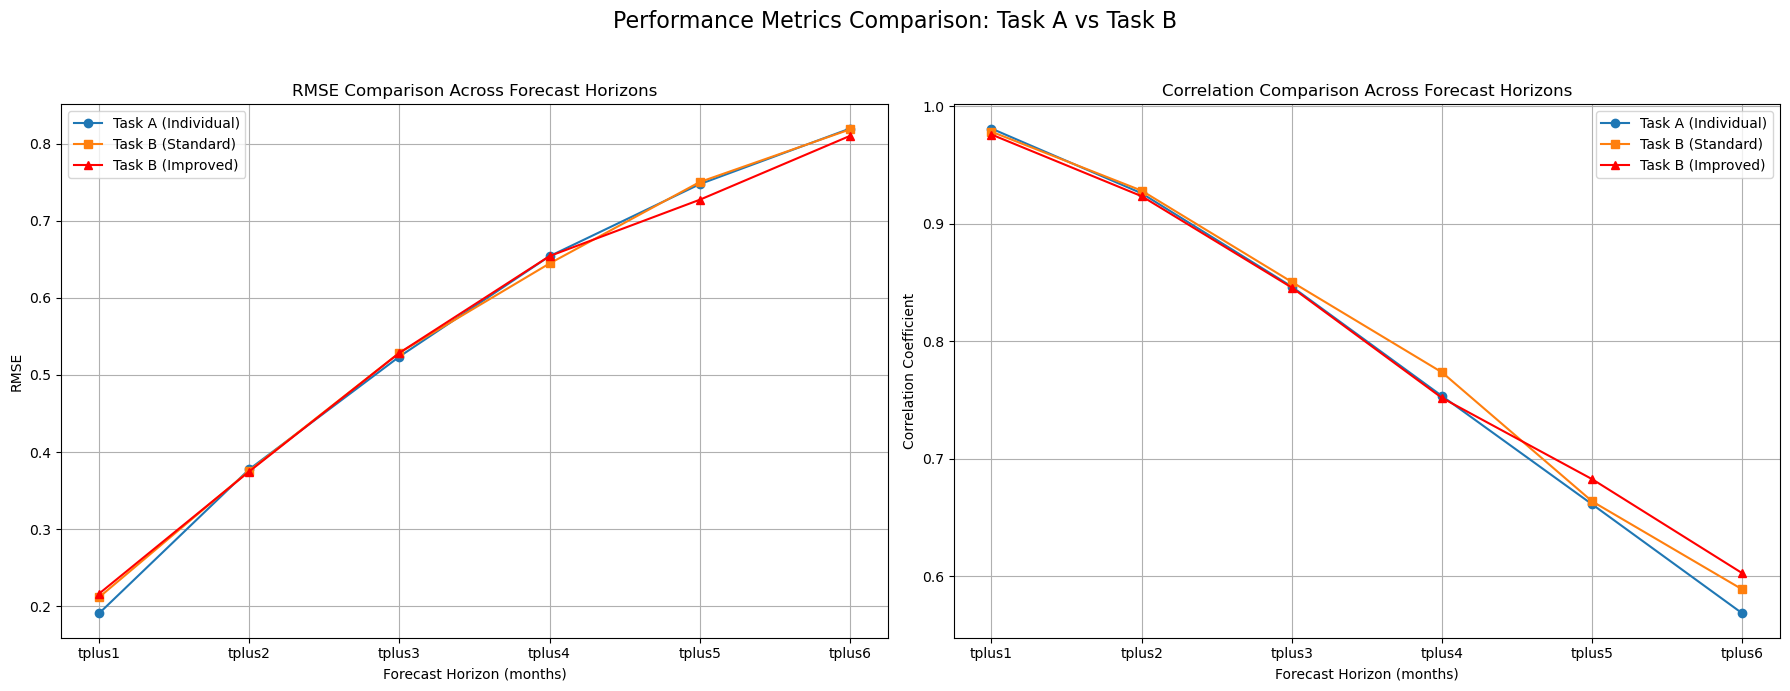

In [15]:
'''

Comparison Requirement

'''
input_dim = X_test_scaled.shape[1]
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
horizons = [f'nino_tplus{i}' for i in range(1, 7)]
results = {}

task_a_results = {'RMSE': [], 'Correlation': []}
for target in horizons:
    model = RegressionNN(input_dim, 1)
    model.load_state_dict(torch.load(f'model_{target}.pth'))
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).numpy().flatten()
    trues = test_set[target].values
    task_a_results['RMSE'].append(rmse(trues, preds))
    task_a_results['Correlation'].append(pearson_correlation(trues, preds))
results['Task A (Individual)'] = task_a_results

model_b_std = MultiOutputNN(input_dim, 6)
model_b_std.load_state_dict(torch.load('model_taskB.pth'))
model_b_std.eval()
with torch.no_grad():
    preds_b_std = model_b_std(X_test_tensor).numpy()

task_b_std_results = {'RMSE': [], 'Correlation': []}
for i, target in enumerate(horizons):
    trues = test_set[target].values
    preds = preds_b_std[:, i]
    task_b_std_results['RMSE'].append(rmse(trues, preds))
    task_b_std_results['Correlation'].append(pearson_correlation(trues, preds))
results['Task B (Standard)'] = task_b_std_results

model_b_imp = MultiOutputNN(input_dim, 6)
model_b_imp.load_state_dict(torch.load('improved_model_taskB.pth'))
model_b_imp.eval()
with torch.no_grad():
    preds_b_imp = model_b_imp(X_test_tensor).numpy()

task_b_imp_results = {'RMSE': [], 'Correlation': []}
for i, target in enumerate(horizons):
    trues = test_set[target].values
    preds = preds_b_imp[:, i]
    task_b_imp_results['RMSE'].append(rmse(trues, preds))
    task_b_imp_results['Correlation'].append(pearson_correlation(trues, preds))
results['Task B (Improved)'] = task_b_imp_results


df_list = []
for model_name, model_results in results.items():
    df = pd.DataFrame(model_results, index=[f'tplus{i}' for i in range(1, 7)])
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])
    df_list.append(df)

summary_table = pd.concat(df_list, axis=1)

print(summary_table.round(4)) 

# Visualization

horizon_labels = [f'tplus{i}' for i in range(1, 7)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Performance Metrics Comparison: Task A vs Task B', fontsize=16)

# RMSE
ax = axes[0]
ax.plot(horizon_labels, results['Task A (Individual)']['RMSE'], marker='o', linestyle='-', label='Task A (Individual)')
ax.plot(horizon_labels, results['Task B (Standard)']['RMSE'], marker='s', linestyle='-', label='Task B (Standard)')
ax.plot(horizon_labels, results['Task B (Improved)']['RMSE'], marker='^', c='r', linestyle='-', label='Task B (Improved)')
ax.set_title('RMSE Comparison Across Forecast Horizons')
ax.set_xlabel('Forecast Horizon (months)')
ax.set_ylabel('RMSE')
ax.grid(True)
ax.legend()
#Correlation
ax = axes[1]
ax.plot(horizon_labels, results['Task A (Individual)']['Correlation'], marker='o', linestyle='-', label='Task A (Individual)')
ax.plot(horizon_labels, results['Task B (Standard)']['Correlation'], marker='s', linestyle='-', label='Task B (Standard)')
ax.plot(horizon_labels, results['Task B (Improved)']['Correlation'], marker='^', c='r', linestyle='-', label='Task B (Improved)')
ax.set_title('Correlation Comparison Across Forecast Horizons')
ax.set_xlabel('Forecast Horizon (months)')
ax.set_ylabel('Correlation Coefficient')
ax.grid(True)
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
'''

Test Script

'''

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import pickle
import os

#Model architecture
class RegressionNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(RegressionNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), 
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )
    def forward(self, x):
        return self.network(x)

class MultiOutputNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(MultiOutputNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        return self.network(x)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pearson_correlation(y_true, y_pred):
    corr, _ = pearsonr(y_true.flatten(), y_pred.flatten())
    return corr


hidden_data_path = 'Hidden_Dataset/Nino3.4_data_hidden.csv'
scaler_path = 'feature_scaler.pkl' 
input_features = ['nino_tminus2', 'nino_tminus1', 'nino_t']
horizons = [f'nino_tplus{i}' for i in range(1, 7)]


if not os.path.exists(hidden_data_path):
    print(f"Error: can't find '{hidden_data_path}'.")
else:
    print("=====================================================")
    print("      Final Evaluation on Hidden Test Set")
    print("=====================================================")

    hidden_df = pd.read_csv(hidden_data_path)
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)

    X_hidden = hidden_df[input_features]
    X_hidden_scaled = scaler.transform(X_hidden)
    X_hidden_tensor = torch.tensor(X_hidden_scaled, dtype=torch.float32)

    print("\n--- Task A Models ---")
    task_a_models = horizons + ['nino_tplus6_transferlearning']
    for model_name in task_a_models:
        model = RegressionNN(input_size=len(input_features), output_size=1)
        model_path = f'model_{model_name}.pth'
        model.load_state_dict(torch.load(model_path))
        model.eval()
        
        with torch.no_grad():
            preds = model(X_hidden_tensor).numpy().flatten()
        
        true_target_col = model_name.replace('_transferlearning', '')
        trues = hidden_df[true_target_col].values
        
        rmse_score = rmse(trues, preds)
        corr_score = pearson_correlation(trues, preds)
        
        print(f"{model_name:<25}: RMSE={rmse_score:.4f}, Correlation={corr_score:.4f}")

    print("\n--- Task B Models ---")
    task_b_models = {
        'Task B (Standard)': 'model_taskB.pth',
        'Task B (Improved)': 'improved_model_taskB.pth'
    }
    
    for model_name, model_path in task_b_models.items():
        model = MultiOutputNN(input_size=len(input_features), output_size=6)
        model.load_state_dict(torch.load(model_path))
        model.eval()

        with torch.no_grad():
            preds_all = model(X_hidden_tensor).numpy()

        for i, target in enumerate(horizons):
            preds = preds_all[:, i]
            trues = hidden_df[target].values
            
            rmse_score = rmse(trues, preds)
            corr_score = pearson_correlation(trues, preds)
            
            print(f"  - {model_name}-{target:<12}: RMSE={rmse_score:.4f}, Correlation={corr_score:.4f}")



      Final Evaluation on Hidden Test Set

--- Task A Models ---
nino_tplus1              : RMSE=0.1941, Correlation=0.9724
nino_tplus2              : RMSE=0.3294, Correlation=0.9198
nino_tplus3              : RMSE=0.4316, Correlation=0.8570
nino_tplus4              : RMSE=0.5469, Correlation=0.7573
nino_tplus5              : RMSE=0.6295, Correlation=0.6546
nino_tplus6              : RMSE=0.7203, Correlation=0.5053
nino_tplus6_transferlearning: RMSE=0.7013, Correlation=0.5385

--- Task B Models ---
  - Task B (Standard)-nino_tplus1 : RMSE=0.2008, Correlation=0.9705
  - Task B (Standard)-nino_tplus2 : RMSE=0.3323, Correlation=0.9182
  - Task B (Standard)-nino_tplus3 : RMSE=0.4450, Correlation=0.8499
  - Task B (Standard)-nino_tplus4 : RMSE=0.5449, Correlation=0.7650
  - Task B (Standard)-nino_tplus5 : RMSE=0.6364, Correlation=0.6472
  - Task B (Standard)-nino_tplus6 : RMSE=0.7129, Correlation=0.5213
  - Task B (Improved)-nino_tplus1 : RMSE=0.2064, Correlation=0.9686
  - Task B (Improved